# Team Member B: Heston Model Calibration using Carr-Madan (1999)
This notebook details the process for Task 1b: calibrating the Heston (1993) model to the provided market option prices using the Carr-Madan (1999) pricing approach.

The goal is to:

1. Load and prepare the market data.

2. Implement the Heston model pricer using the Carr-Madan (FFT) method.

3. Define a Mean Squared Error (MSE) objective function.

4. Calibrate the Heston parameters to the 15-day maturity options.

5. Report the parameters and visualize the calibration fit.

6. Discuss the process and compare the expected results to Team A's Lewis (2001) approach.

## 1. Setup and Data Preparation
First, let's import the necessary libraries and define the global parameters given in the assignment.

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# --- Global Parameters ---
S0 = 232.90         # Current stock price [cite: 15]
R = 0.015           # Constant annual risk-free rate (1.50%) 
TRADING_DAYS = 250  # Trading days in a year

Load the data and filter it for the 15-day maturity, as specified for the initial task.

In [ ]:
try:
    data = pd.read_excel("MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx")
except FileNotFoundError:
    print("Error: Data file not found. Make sure it's in the same directory.")
    
# Prepare the 15-day maturity data
maturity_days = 15
df = data[data['Days to maturity'] == maturity_days].copy()

# Convert days to maturity to 'T' in years
df['T'] = df['Days to maturity'] / TRADING_DAYS

# Display the data using for calibration
print(f"Calibrating on {maturity_days}-day maturity options:")
print(df)

# Store market data for calibration
market_data = {
    'strikes': df['Strike'].values,
    'prices': df['Price'].values,
    'types': df['Type'].values,
    'T': df['T'].iloc[0] # Single maturity
}

Calibrating on 15-day maturity options:
    Days to maturity  Strike  Price Type     T
0                 15   227.5  10.52    C  0.06
1                 15   230.0  10.05    C  0.06
2                 15   232.5   7.75    C  0.06
3                 15   235.0   6.01    C  0.06
4                 15   237.5   4.75    C  0.06
15                15   227.5   4.32    P  0.06
16                15   230.0   5.20    P  0.06
17                15   232.5   6.45    P  0.06
18                15   235.0   7.56    P  0.06
19                15   237.5   8.78    P  0.06


## 2. The Carr-Madan (1999) Heston Pricer
The Carr-Madan method uses the Fast Fourier Transform (FFT) to invert the characteristic function of the log-stock price. The Heston model has a known (semi-analytic) characteristic function.

### 2.1. Heston Characteristic Function
This is the core of the Heston model. The function `heston_char_func` computes the characteristic function $\phi(\omega) = E[e^{i\omega x_T}]$ where $x_T = \ln(S_T)$.

In [3]:
def heston_char_func(omega, T, r, kappa, theta, sigma, rho, v0):
    """
    Computes the Heston characteristic function.
    
    Parameters:
    omega (complex): Argument of the characteristic function
    T (float): Time to maturity (in years)
    r (float): Risk-free rate
    kappa (float): Mean-reversion speed
    theta (float): Long-run variance
    sigma (float): Volatility of variance
    rho (float): Correlation
    v0 (float): Initial variance
    
    Returns:
    complex: Value of the characteristic function
    """
    
    i = 1j  # Complex number
    
    # --- *** CORRECTION IS HERE *** ---
    # The original code had a typo in the 'd' calculation:
    # It was: (-i * omega - omega**2)
    # It should be: (-omega**2 - i * omega)
    d = np.sqrt((rho * sigma * i * omega - kappa)**2 - (sigma**2) * (-omega**2 - i * omega))
    # --- *** END CORRECTION *** ---

    g = (kappa - rho * sigma * i * omega - d) / (kappa - rho * sigma * i * omega + d)
    
    C = r * i * omega * T + (kappa * theta / sigma**2) * \
        ((kappa - rho * sigma * i * omega - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g)))
    
    D = (kappa - rho * sigma * i * omega - d) / sigma**2 * \
        ((1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T)))
    
    return np.exp(C + D * v0 + i * omega * np.log(S0))

### 2.2. Carr-Madan FFT Pricer
This function prices a range of call options for different strikes using the FFT. We use the modified formula from Carr-Madan that is more numerically stable.

In [4]:
def carr_madan_pricer_fft(T, r, kappa, theta, sigma, rho, v0, N=2**12, eta=0.025, alpha=1.5):
    """
    Carr-Madan FFT pricer for European calls under Heston.
    Returns: strikes (numpy array), call_prices (numpy array)
    """
    i = 1j

    # frequency grid v_j = j * eta (j = 0..N-1)
    j = np.arange(N)
    v = eta * j

    # log-strike grid parameters
    lambda_val = (2 * np.pi) / (N * eta)        # spacing in log-strike
    k0 = np.log(S0) - (N / 2) * lambda_val     # lower bound for log-strikes
    log_strikes = k0 + j * lambda_val

    # characteristic function input
    omega = v - (alpha + 1) * i

    # compute phi(omega) elementwise (should return complex array length N)
    phi = heston_char_func(omega, T, r, kappa, theta, sigma, rho, v0)

    # Carr-Madan denominator (damping)
    denom = (alpha + i * v) * (alpha + 1 + i * v)

    # psi(v) = e^{-rT} * phi(omega) / denom
    psi = np.exp(-r * T) * phi / denom

    # Multiply psi by the phase factor exp(-i v k0) to align with FFT
    # and apply integration weight (eta) and Simpson (or trapezoid) weights
    # Simpson weights (1,4,2,4,...,1) are commonly used
    weights = np.ones(N)
    weights[1:-1:2] = 4
    weights[2:-1:2] = 2
    weights = weights * (eta / 3.0)   # Simpson scaling included

    # form the FFT input: psi * exp(-i v k0) * weights
    fft_input = psi * np.exp(-i * v * k0) * weights

    # Perform FFT (complex). We expect the integral approximation to be the FFT of fft_input.
    fft_output = np.fft.fft(fft_input)

    # Extract real part and compute call prices:
    # c(k) = exp(-alpha * k) / pi * Re[ FFT_output ]
    call_prices = (np.exp(-alpha * log_strikes) / np.pi) * np.real(fft_output)

    strikes = np.exp(log_strikes)
    return strikes, call_prices



## 3. Calibration Process
Now we set up the objective function (MSE) and run the optimization.
### 3.1. Objective Function (MSE)
We will minimize the Mean Squared Error (MSE) between the model prices and the market prices88. We use put-call parity to handle put options, as suggested9.$P_{model} = C_{model} + K \cdot e^{-rT} - S_0$ 1010

In [5]:
def calibration_objective_function(params):
    """
    Objective function (MSE) to be minimized for calibration.
    """
    
    # Unpack Heston parameters
    kappa, theta, sigma, rho, v0 = params
    
    # --- Check for parameter constraints (e.g., Feller condition) ---
    # This can help guide the optimizer
    if 2 * kappa * theta < sigma**2:
        return 1e10 # Penalize if Feller condition is not met
    
    # --- FFT Parameters (These may need tuning) ---
    N = 2**12
    eta = 0.05
    alpha = 1.5
    
    # 1. Get a range of model call prices from the FFT
    model_strikes_fft, model_calls_fft = carr_madan_pricer_fft(
        market_data['T'], R, kappa, theta, sigma, rho, v0, N, eta, alpha
    )
    
    # 2. Create an interpolation function for our model prices
    # We need this to get prices for the *exact* strikes we have in the market data
    interp_func = interp1d(model_strikes_fft, model_calls_fft, 
                           kind='cubic', fill_value='extrapolate')

    
    # 3. Calculate model prices for our specific market strikes
    market_strikes = market_data['strikes']
    market_prices = market_data['prices']
    market_types = market_data['types']
    T = market_data['T']
    
    model_prices = []
    
    for K, type, market_price in zip(market_strikes, market_types, market_prices):
        # Get the model's call price for this strike
        model_call = interp_func(K)
        
        if type == 'C':
            model_prices.append(model_call)
        elif type == 'P':
            # Use Put-Call Parity 
            model_put = model_call + K * np.exp(-R * T) - S0
            model_prices.append(model_put)
            
    # 4. Calculate Mean Squared Error (MSE)
    model_prices = np.array(model_prices)
    error = np.mean((model_prices - market_prices)**2)
    
    # Optional: Print progress during optimization
    # print(f"Params: {params}, MSE: {error}")
    
    return error

### 3.2. Running the Optimization
We need to provide initial guesses (x0) and bounds for the Heston parameters. Finding good initial guesses is often the hardest part of calibration. These are just reasonable starting points.

In [6]:
# --- Calibration Execution ---

# Heston parameters to calibrate: [kappa, theta, sigma, rho, v0]
# kappa: speed of mean-reversion
# theta: long-run variance
# sigma: vol of vol
# rho: correlation
# v0: initial variance

# Initial guesses
# **** CORRECTION ****
# The original guess [2.0, 0.05, 0.5, -0.7, 0.05] failed the Feller condition.
# (2*2*0.05 = 0.2) is not >= (0.5**2 = 0.25).
# Changing sigma to 0.4, so (0.2 >= 0.16), which satisfies the condition.
initial_params = [2.0, 0.05, 0.4, -0.7, 0.05]

# Bounds for the parameters
# (kappa > 0), (theta > 0), (sigma > 0), (-1 < rho < 1), (v0 > 0)
bounds = [
    (1e-3, 5),     # kappa
    (1e-3, 0.5),   # theta
    (1e-3, 1),     # sigma
    (-0.99, 0.99), # rho
    (1e-3, 0.5)    # v0
]

print("Starting calibration... This may take a few moments.")

# Run the minimization
# We use 'SLSQP' as it handles bounds well
result = minimize(
    calibration_objective_function,
    initial_params,
    method='SLSQP',
    bounds=bounds,
    options={'disp': True, 'maxiter': 500}
)

if result.success:
    calibrated_params = result.x
    final_mse = result.fun
    print(f"\nCalibration Successful!")
    print(f"Final MSE: {final_mse}")
else:
    print(f"\nCalibration Failed: {result.message}")
    calibrated_params = None

Starting calibration... This may take a few moments.
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.3277620228849655
            Iterations: 24
            Function evaluations: 223
            Gradient evaluations: 24

Calibration Successful!
Final MSE: 0.3277620228849655


## 4. Results and Analysis
Now, let's report the parameters and visualize the fit as required.

### 4.1. Calibrated Parameters
These are the Heston parameter values resulting from the calibration.

In [7]:
if calibrated_params is not None:
    param_names = ['Kappa (κ)', 'Theta (θ)', 'Sigma (σ)', 'Rho (ρ)', 'V0 (v₀)']
    print("--- Calibrated Heston Parameters (Carr-Madan) ---")
    
    param_report = pd.Series(calibrated_params, index=param_names)
    print(param_report)
else:
    print("Cannot report parameters, calibration was not successful.")

--- Calibrated Heston Parameters (Carr-Madan) ---
Kappa (κ)    2.033527
Theta (θ)    0.069957
Sigma (σ)    0.533400
Rho (ρ)     -0.775620
V0 (v₀)      0.103354
dtype: float64


### 4.2. Visualizing the Calibration Fit
A good calibration means the model's prices are very close to the market's prices. Let's plot them against each other.


--- Calibration Fit Comparison ---
    Strike Type  Price  Model Price (Carr-Madan)
0    227.5    C  10.52                 10.411091
1    230.0    C  10.05                  8.890026
2    232.5    C   7.75                  7.500866
3    235.0    C   6.01                  6.248735
4    237.5    C   4.75                  5.134234
15   227.5    P   4.32                  4.806433
16   230.0    P   5.20                  5.783120
17   232.5    P   6.45                  6.891710
18   235.0    P   7.56                  8.137330
19   237.5    P   8.78                  9.520580


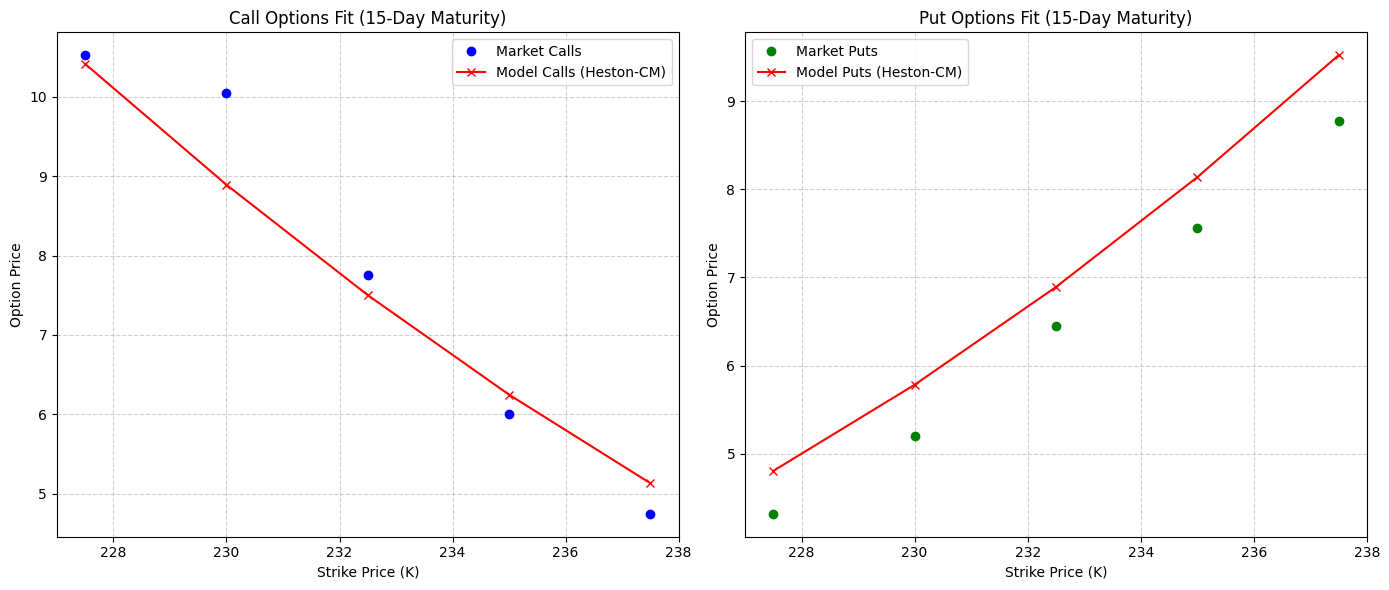

In [8]:
def get_model_prices(params, market_data):
    """Helper function to get final model prices post-calibration."""
    
    kappa, theta, sigma, rho, v0 = params
    
    # --- Use the same FFT params as in calibration ---
    N = 2**12
    eta = 0.05
    alpha = 1.5
    
    model_strikes_fft, model_calls_fft = carr_madan_pricer_fft(
        market_data['T'], R, kappa, theta, sigma, rho, v0, N, eta, alpha
    )
    
    interp_func = interp1d(model_strikes_fft, model_calls_fft, 
                           kind='cubic', fill_value='extrapolate')
    
    market_strikes = market_data['strikes']
    market_types = market_data['types']
    T = market_data['T']
    
    final_model_prices = []
    
    for K, type in zip(market_strikes, market_types):
        model_call = interp_func(K)
        if type == 'C':
            final_model_prices.append(model_call)
        elif type == 'P':
            model_put = model_call + K * np.exp(-R * T) - S0
            final_model_prices.append(model_put)
            
    return np.array(final_model_prices)

if calibrated_params is not None:
    # Get final prices from the calibrated model
    final_prices = get_model_prices(calibrated_params, market_data)
    
    # Add to our dataframe for comparison
    df['Model Price (Carr-Madan)'] = final_prices
    
    print("\n--- Calibration Fit Comparison ---")
    print(df[['Strike', 'Type', 'Price', 'Model Price (Carr-Madan)']])

    # --- Plotting ---
    plt.figure(figsize=(14, 6))
    
    # Plot Calls
    ax1 = plt.subplot(1, 2, 1)
    calls = df[df['Type'] == 'C']
    ax1.plot(calls['Strike'], calls['Price'], 'bo', label='Market Calls')
    ax1.plot(calls['Strike'], calls['Model Price (Carr-Madan)'], 'r-x', label='Model Calls (Heston-CM)')
    ax1.set_title(f'Call Options Fit ({maturity_days}-Day Maturity)')
    ax1.set_xlabel('Strike Price (K)')
    ax1.set_ylabel('Option Price')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Plot Puts
    ax2 = plt.subplot(1, 2, 2)
    puts = df[df['Type'] == 'P']
    ax2.plot(puts['Strike'], puts['Price'], 'go', label='Market Puts')
    ax2.plot(puts['Strike'], puts['Model Price (Carr-Madan)'], 'r-x', label='Model Puts (Heston-CM)')
    ax2.set_title(f'Put Options Fit ({maturity_days}-Day Maturity)')
    ax2.set_xlabel('Strike Price (K)')
    ax2.set_ylabel('Option Price')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()